# 🌲 Teen Mental Health — Random Forest Classification
**Dataset:** Teen_Mental_Health_Dataset.csv  
**Target:** `depression_label` (0 = Tidak Depresi, 1 = Depresi)  
**Alur:** Import → EDA → Preprocessing → SMOTE → Training → Evaluasi → Feature Importance → Cross Validation

---
## 📦 Cell 1 — Install Library

In [2]:
# Jalankan cell ini jika library belum terinstall
%pip install imbalanced-learn scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📚 Cell 2 — Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

import sklearn
print('✅ Semua library berhasil diimport!')
print(f'   Scikit-learn versi : {sklearn.__version__}')

✅ Semua library berhasil diimport!
   Scikit-learn versi : 1.8.0


---
## 📂 Cell 3 — Load Dataset

In [3]:
# Sesuaikan path jika file CSV tidak satu folder dengan notebook ini
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print('=' * 50)
print(f'  Jumlah baris   : {df.shape[0]}')
print(f'  Jumlah kolom   : {df.shape[1]}')
print('=' * 50)
df.head(10)

  Jumlah baris   : 1200
  Jumlah kolom   : 13


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


---
## 🔍 Cell 4 — Exploratory Data Analysis (EDA)

In [4]:
# Info tipe data dan missing values
print('--- Info Dataset ---')
df.info()
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Statistik Deskriptif ---')
df.describe()

--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 K

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


--- Distribusi Target: depression_label ---
  Kelas 0 : 1169 sampel (97.42%)
  Kelas 1 : 31 sampel (2.58%)


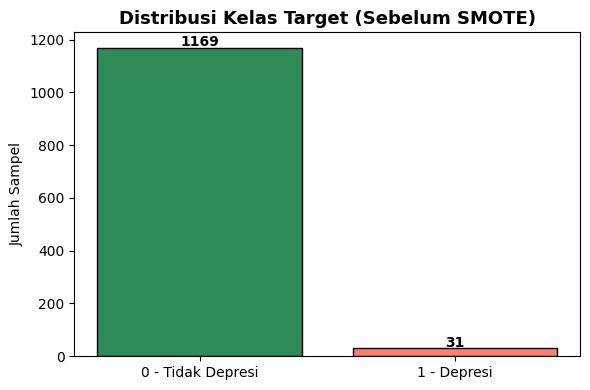

In [5]:
# Distribusi Target (Imbalance Check)
target_counts = df['depression_label'].value_counts()
target_pct    = df['depression_label'].value_counts(normalize=True) * 100

print('--- Distribusi Target: depression_label ---')
for label, count in target_counts.items():
    print(f'  Kelas {label} : {count} sampel ({target_pct[label]:.2f}%)')

plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['0 - Tidak Depresi', '1 - Depresi'],
    target_counts.values,
    color=['seagreen', 'salmon'],
    edgecolor='black'
)
for bar, count in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontweight='bold')
plt.title('Distribusi Kelas Target (Sebelum SMOTE)', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

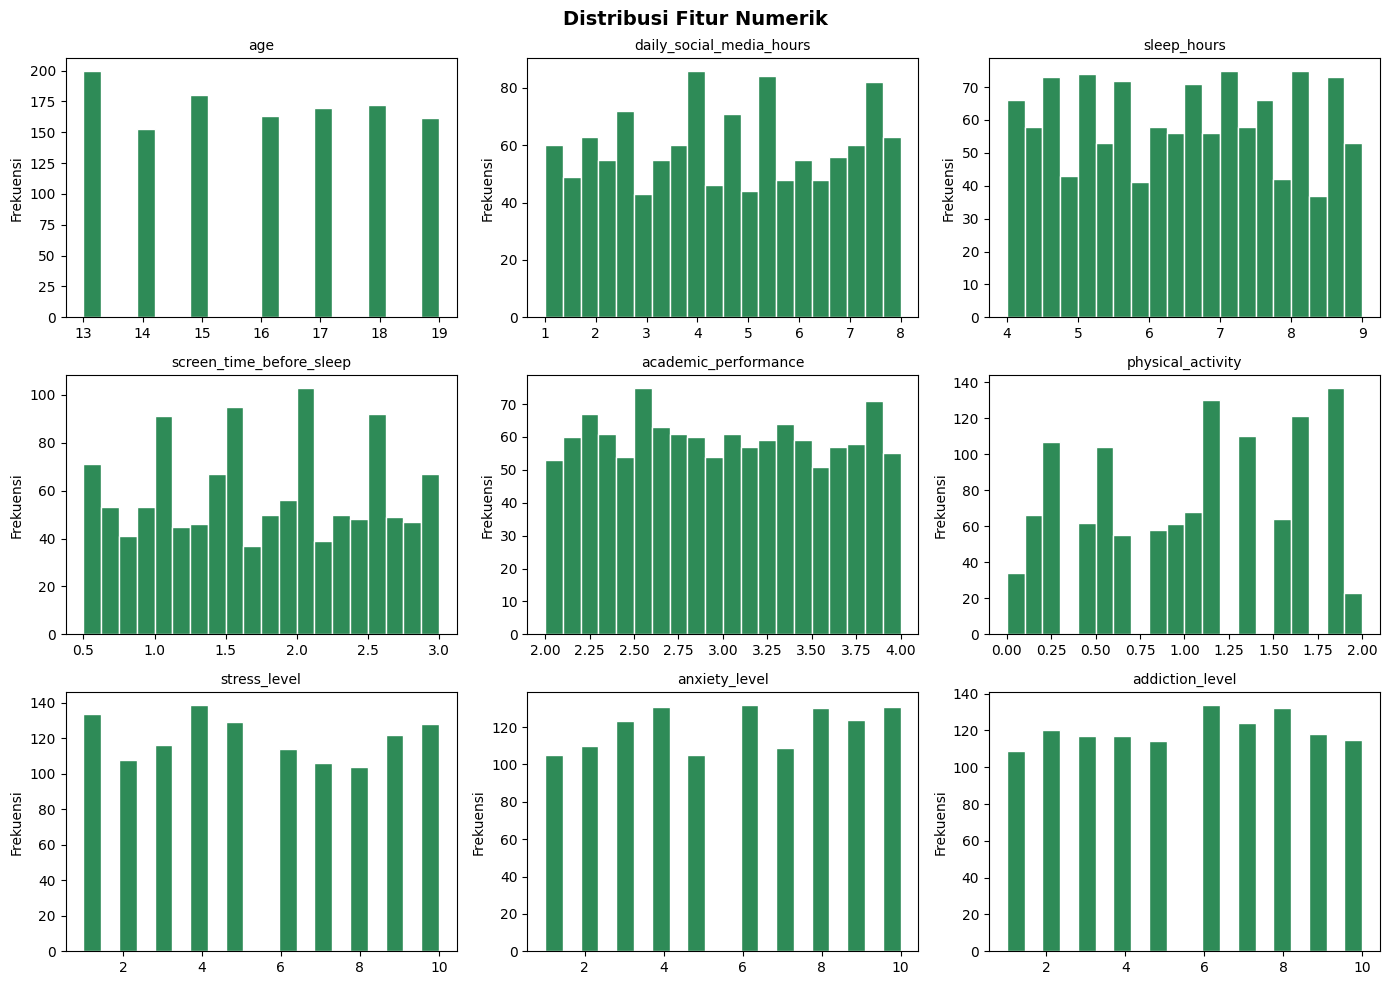

In [6]:
# Distribusi Fitur Numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('depression_label')

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color='seagreen', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

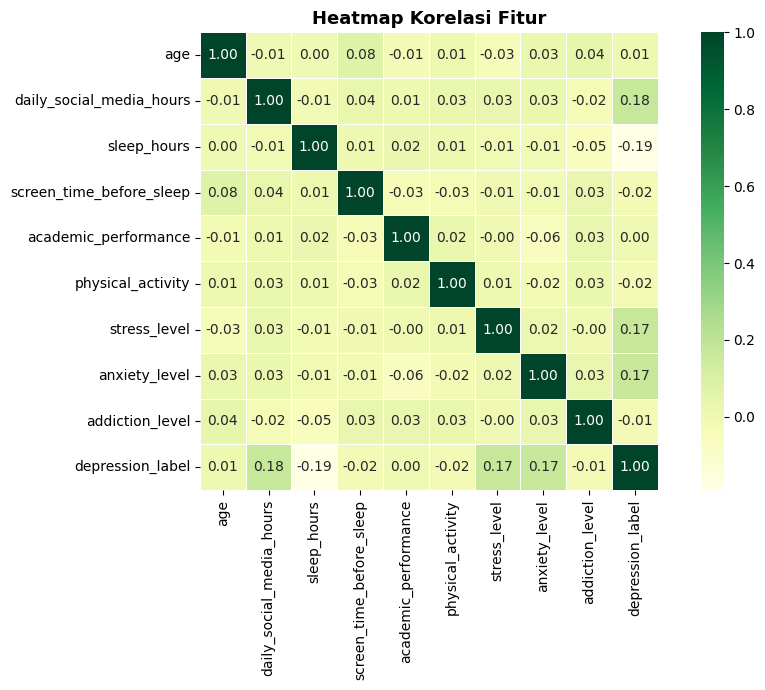

In [7]:
# Heatmap Korelasi
plt.figure(figsize=(10, 7))
corr = df[num_cols + ['depression_label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

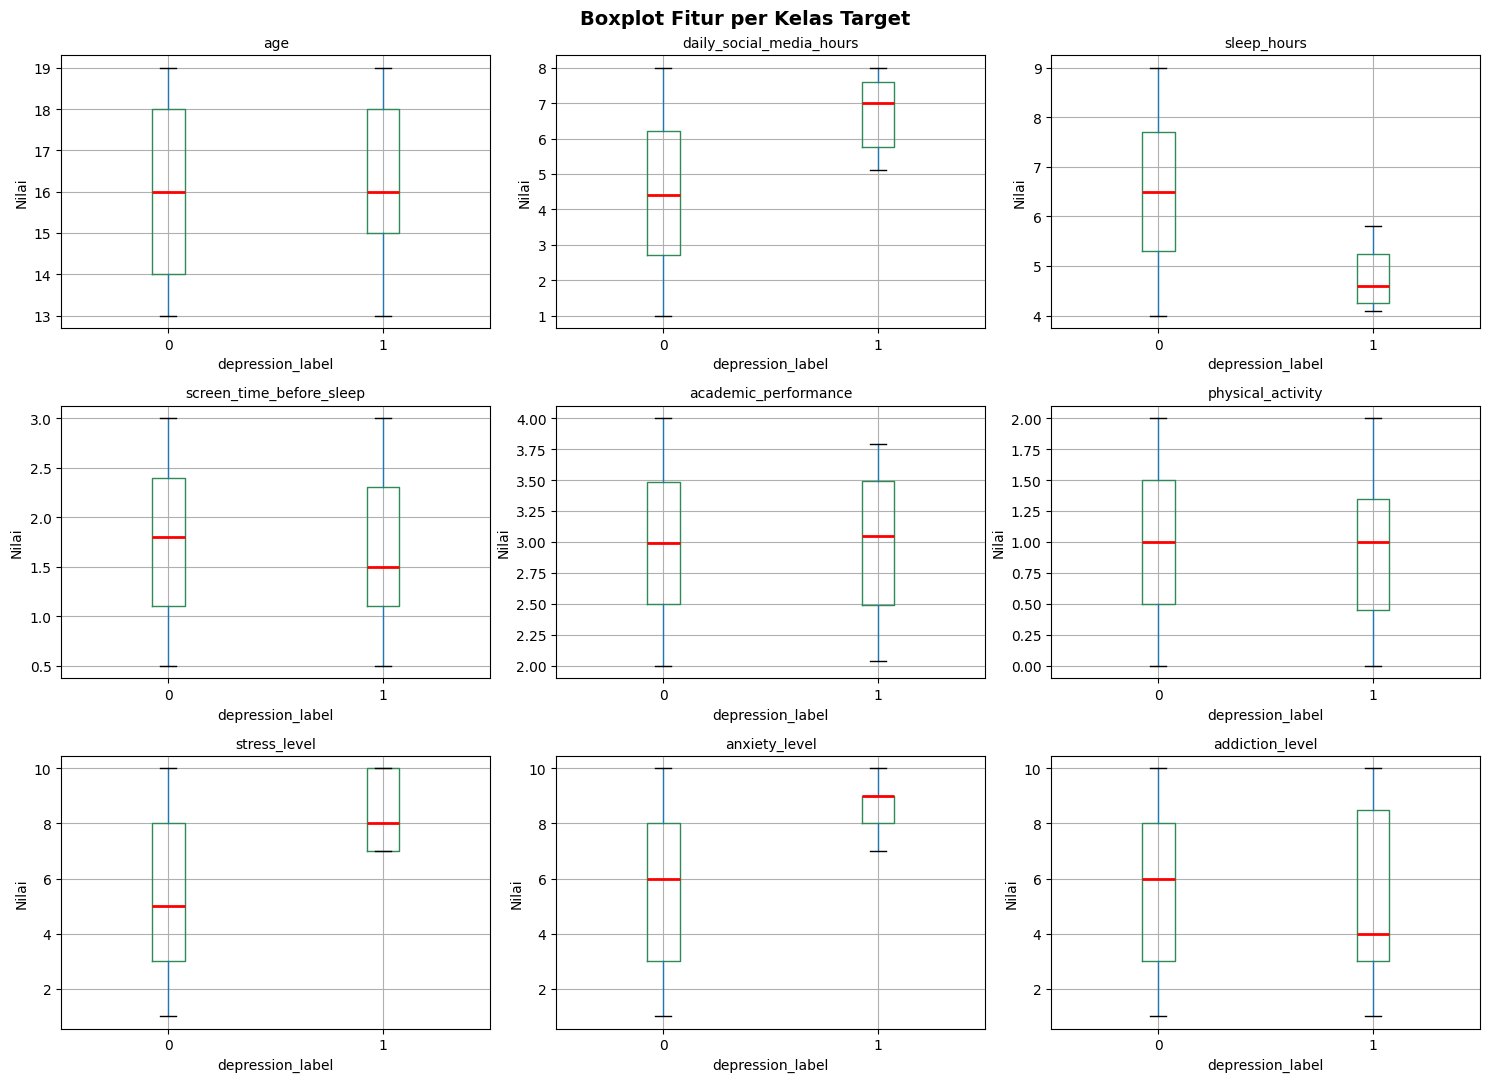

In [8]:
# Boxplot Fitur Numerik berdasarkan Kelas Target
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='depression_label', ax=axes[i],
               boxprops=dict(color='seagreen'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('depression_label')
    axes[i].set_ylabel('Nilai')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur per Kelas Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Cell 5 — Preprocessing

In [9]:
df_model = df.copy()

# Encode kolom kategorikal
le = LabelEncoder()
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'  ✅ Encoded "{col}" -> {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Pisahkan fitur dan target
X = df_model.drop('depression_label', axis=1)
y = df_model['depression_label']

# Split data (stratify agar proporsi kelas terjaga)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print()
print(f'  Total data           : {len(X)}')
print(f'  Data train           : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Data test            : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'  Fitur yang digunakan : {list(X.columns)}')

  ✅ Encoded "gender" -> {'female': np.int64(0), 'male': np.int64(1)}
  ✅ Encoded "platform_usage" -> {'Both': np.int64(0), 'Instagram': np.int64(1), 'TikTok': np.int64(2)}
  ✅ Encoded "social_interaction_level" -> {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

  Total data           : 1200
  Data train           : 960 (80%)
  Data test            : 240 (20%)
  Fitur yang digunakan : ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level']


---
## ⚖️ Cell 6 — Mengatasi Imbalance Data dengan SMOTE

Distribusi kelas SEBELUM SMOTE:
  Counter({0: 935, 1: 25})

Distribusi kelas SETELAH SMOTE:
  Counter({0: 935, 1: 935})


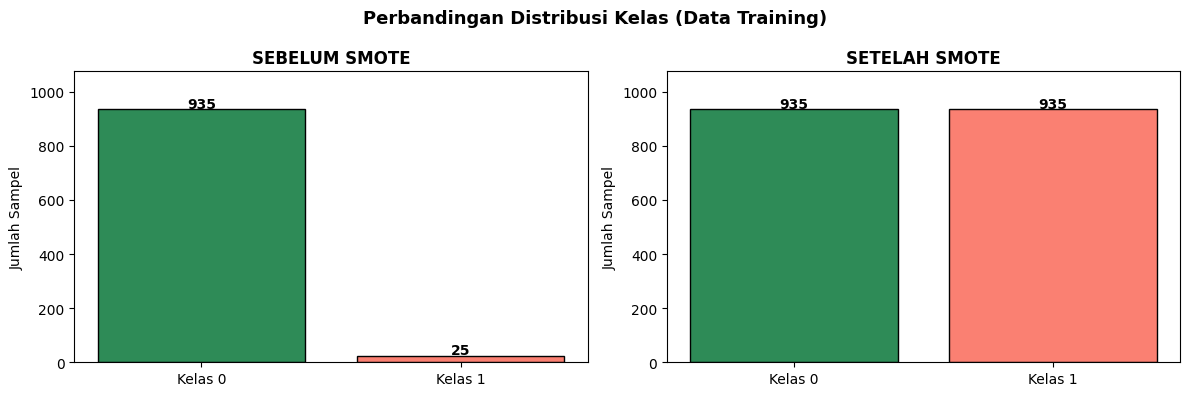


  Data train sebelum SMOTE : 960 sampel
  Data train setelah SMOTE  : 1870 sampel
  ⚠️  Data test TIDAK diubah (tetap data asli untuk evaluasi realistis)


In [10]:
print('Distribusi kelas SEBELUM SMOTE:')
print(f'  {Counter(y_train)}')

# Apply SMOTE hanya pada data training
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print()
print('Distribusi kelas SETELAH SMOTE:')
print(f'  {Counter(y_train_smote)}')

# Visualisasi perbandingan sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_smote).value_counts()

axes[0].bar(['Kelas 0', 'Kelas 1'], before.values,
            color=['seagreen', 'salmon'], edgecolor='black')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('SEBELUM SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(after.values) * 1.15)

axes[1].bar(['Kelas 0', 'Kelas 1'], after.values,
            color=['seagreen', 'salmon'], edgecolor='black')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('SETELAH SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(after.values) * 1.15)

plt.suptitle('Perbandingan Distribusi Kelas (Data Training)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n  Data train sebelum SMOTE : {X_train.shape[0]} sampel')
print(f'  Data train setelah SMOTE  : {X_train_smote.shape[0]} sampel')
print('  ⚠️  Data test TIDAK diubah (tetap data asli untuk evaluasi realistis)')

---
## 🚀 Cell 7 — Training Model Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators    = 200,
    max_depth       = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features    = 'sqrt',
    random_state    = 42,
    n_jobs          = -1
)

rf_model.fit(X_train_smote, y_train_smote)

print('✅ Model Random Forest selesai dilatih!')
print(f'   Jumlah pohon (n_estimators) : {rf_model.n_estimators}')
print(f'   Max depth                   : {rf_model.max_depth}')
print(f'   Max features                : {rf_model.max_features}')
print(f'   Min samples split           : {rf_model.min_samples_split}')
print(f'   Min samples leaf            : {rf_model.min_samples_leaf}')

✅ Model Random Forest selesai dilatih!
   Jumlah pohon (n_estimators) : 200
   Max depth                   : 10
   Max features                : sqrt
   Min samples split           : 5
   Min samples leaf            : 2


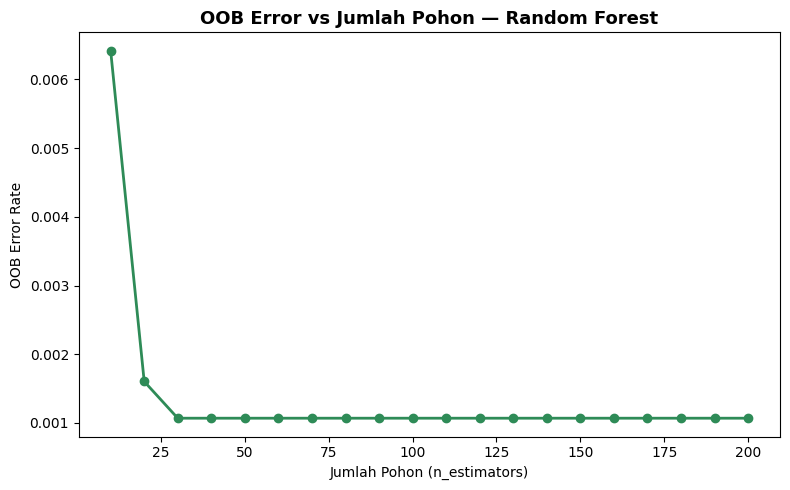

  Jumlah pohon terbaik berdasarkan OOB : 30 (OOB Error = 0.0011)


In [12]:
# Visualisasi OOB Error per Jumlah Pohon
# (training ulang dengan oob_score untuk melihat konvergensi)
oob_errors = []
estimator_range = range(10, 210, 10)

for n in estimator_range:
    clf = RandomForestClassifier(
        n_estimators=n,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_smote, y_train_smote)
    oob_errors.append(1 - clf.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(list(estimator_range), oob_errors, marker='o', color='seagreen', lw=2)
plt.xlabel('Jumlah Pohon (n_estimators)')
plt.ylabel('OOB Error Rate')
plt.title('OOB Error vs Jumlah Pohon — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_n = list(estimator_range)[np.argmin(oob_errors)]
print(f'  Jumlah pohon terbaik berdasarkan OOB : {best_n} (OOB Error = {min(oob_errors):.4f})')

---
## 📊 Cell 8 — Evaluasi Model

In [13]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 47)
print('      HASIL EVALUASI — Random Forest + SMOTE')
print('=' * 47)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 47)
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

      HASIL EVALUASI — Random Forest + SMOTE
  Accuracy  : 0.9958 (99.58%)
  ROC-AUC   : 1.0000

--- Classification Report ---
                   precision    recall  f1-score   support

Tidak Depresi (0)       1.00      1.00      1.00       234
      Depresi (1)       1.00      0.83      0.91         6

         accuracy                           1.00       240
        macro avg       1.00      0.92      0.95       240
     weighted avg       1.00      1.00      1.00       240



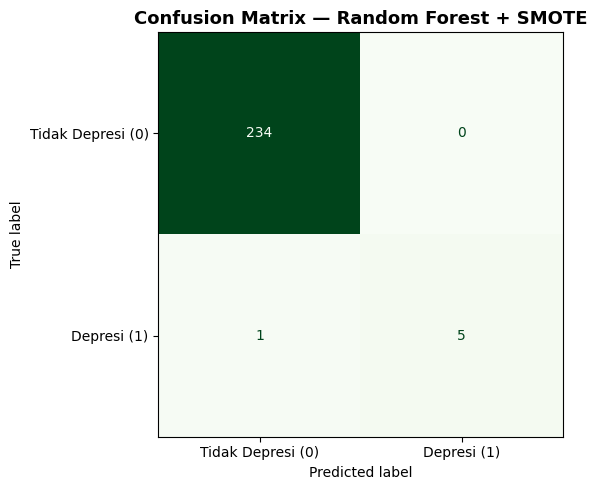

  True Negative  (TN) : 234  → Tidak Depresi, diprediksi benar
  False Positive (FP) : 0  → Tidak Depresi, diprediksi Depresi
  False Negative (FN) : 1  → Depresi, diprediksi Tidak Depresi
  True Positive  (TP) : 5  → Depresi, diprediksi benar


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Depresi (0)', 'Depresi (1)']
)
disp.plot(cmap='Greens', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — Random Forest + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Negative  (TN) : {tn}  → Tidak Depresi, diprediksi benar')
print(f'  False Positive (FP) : {fp}  → Tidak Depresi, diprediksi Depresi')
print(f'  False Negative (FN) : {fn}  → Depresi, diprediksi Tidak Depresi')
print(f'  True Positive  (TP) : {tp}  → Depresi, diprediksi benar')

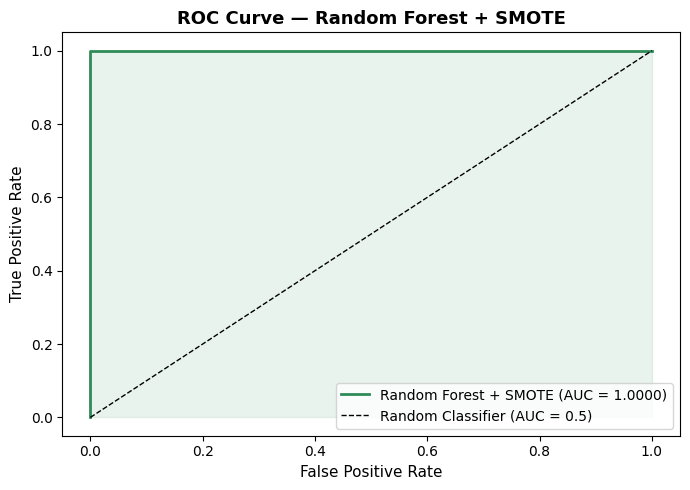

In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='seagreen', lw=2,
         label=f'Random Forest + SMOTE (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='seagreen')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — Random Forest + SMOTE', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 🌟 Cell 9 — Feature Importance

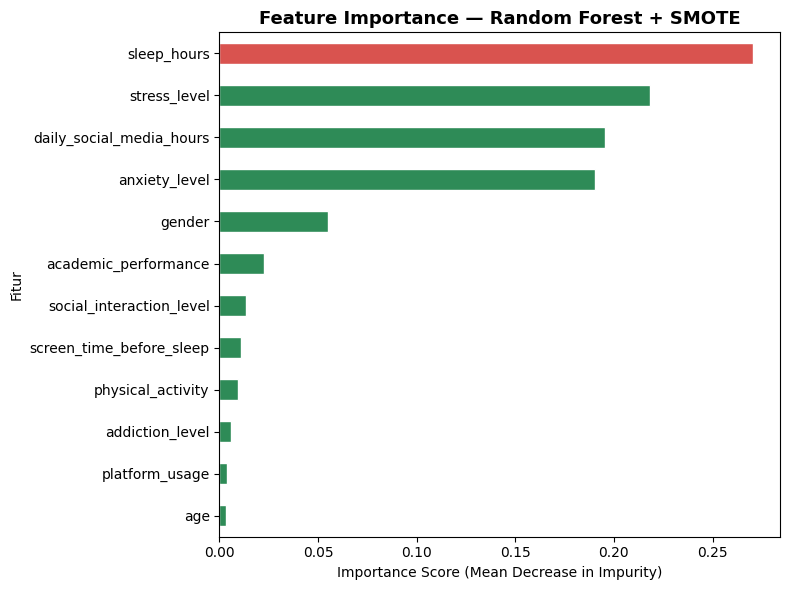

--- Ranking Fitur Terpenting ---
   1. sleep_hours                    : 0.2707
   2. stress_level                   : 0.2185
   3. daily_social_media_hours       : 0.1955
   4. anxiety_level                  : 0.1905
   5. gender                         : 0.0553
   6. academic_performance           : 0.0229
   7. social_interaction_level       : 0.0133
   8. screen_time_before_sleep       : 0.0109
   9. physical_activity              : 0.0093
  10. addiction_level                : 0.0060
  11. platform_usage                 : 0.0038
  12. age                            : 0.0033


In [16]:
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#d9534f' if v == feat_imp.max() else 'seagreen' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest + SMOTE', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print('--- Ranking Fitur Terpenting ---')
for rank, (feat, score) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f'  {rank:2}. {feat:<30} : {score:.4f}')

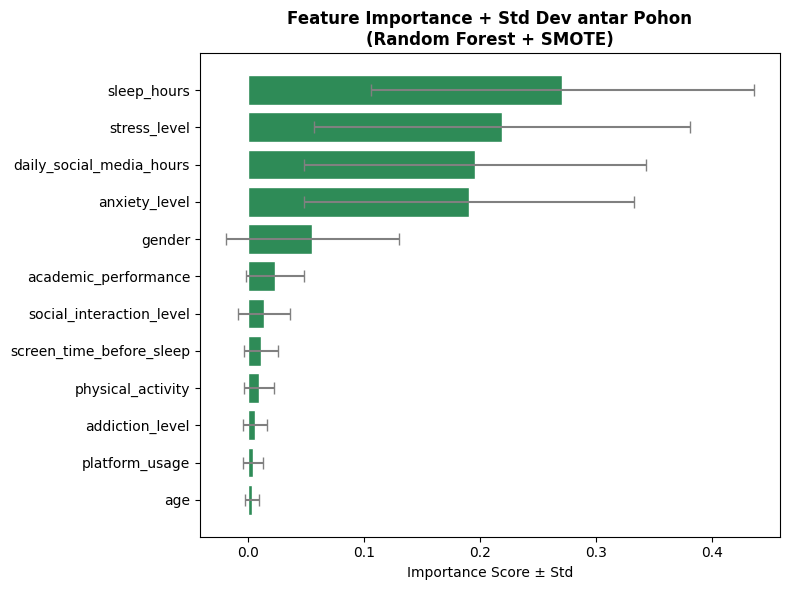

In [17]:
# Feature Importance dengan Error Bar (std antar pohon)
importances = rf_model.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

feat_imp_df = pd.DataFrame({
    'feature'    : X.columns,
    'importance' : importances,
    'std'        : std
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(
    feat_imp_df['feature'],
    feat_imp_df['importance'],
    xerr=feat_imp_df['std'],
    color='seagreen',
    edgecolor='white',
    ecolor='gray',
    capsize=4
)
plt.title('Feature Importance + Std Dev antar Pohon\n(Random Forest + SMOTE)',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score ± Std')
plt.tight_layout()
plt.show()

---
## 🔄 Cell 10 — Cross Validation (5-Fold Stratified)

      CROSS VALIDATION (5-Fold Stratified)
  Accuracy per fold : ['1.0000', '0.9875', '1.0000', '0.9958', '0.9958']
  Mean Accuracy     : 0.9958 ± 0.0046

  AUC per fold      : ['1.0000', '0.9900', '1.0000', '1.0000', '1.0000']
  Mean AUC          : 0.9980 ± 0.0040

  F1 per fold       : ['1.0000', '0.6667', '1.0000', '0.9091', '0.9231']
  Mean F1           : 0.8998 ± 0.1225


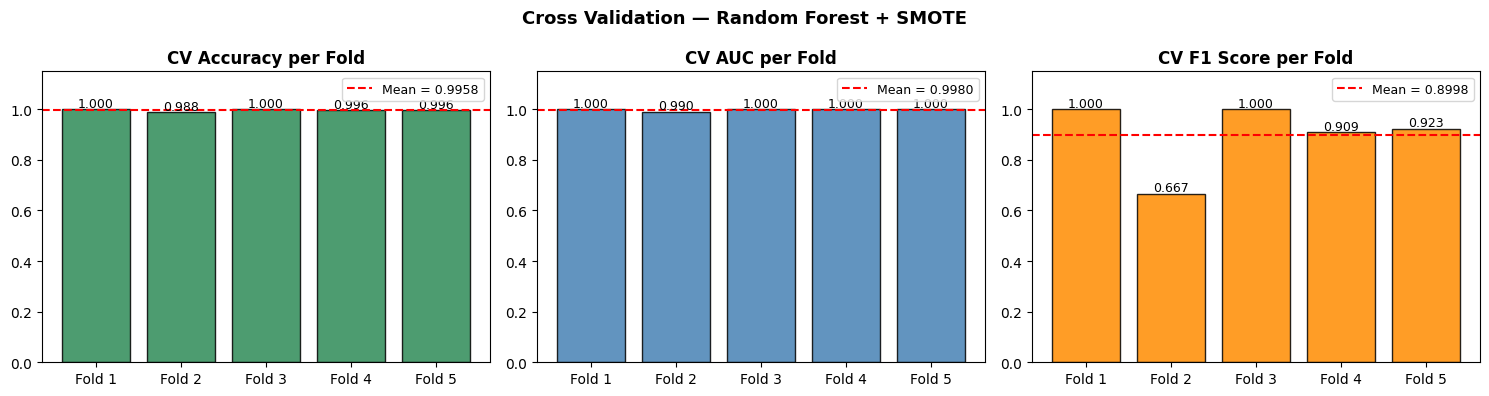

In [18]:
# SMOTE di dalam pipeline agar tidak terjadi data leakage saat CV
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

print('=' * 47)
print('      CROSS VALIDATION (5-Fold Stratified)')
print('=' * 47)
print(f'  Accuracy per fold : {[f"{s:.4f}" for s in cv_acc]}')
print(f'  Mean Accuracy     : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print()
print(f'  AUC per fold      : {[f"{s:.4f}" for s in cv_auc]}')
print(f'  Mean AUC          : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
print(f'  F1 per fold       : {[f"{s:.4f}" for s in cv_f1]}')
print(f'  Mean F1           : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print('=' * 47)

# Visualisasi CV
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fold_labels = [f'Fold {i+1}' for i in range(5)]

metrics = [
    (cv_acc, 'Accuracy', 'seagreen'),
    (cv_auc, 'AUC',      'steelblue'),
    (cv_f1,  'F1 Score', 'darkorange')
]

for ax, (scores, label, color) in zip(axes, metrics):
    ax.bar(fold_labels, scores, color=color, edgecolor='black', alpha=0.85)
    ax.axhline(scores.mean(), color='red', linestyle='--',
               label=f'Mean = {scores.mean():.4f}')
    ax.set_title(f'CV {label} per Fold', fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    for i, v in enumerate(scores):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Cross Validation — Random Forest + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 Cell 11 — Ringkasan Akhir

In [19]:
top_feat = pd.Series(rf_model.feature_importances_, index=X.columns).idxmax()

print('=' * 52)
print('       RINGKASAN HASIL — Random Forest + SMOTE')
print('=' * 52)
print(f'  Dataset              : Teen Mental Health')
print(f'  Total sampel         : {len(df)}')
print(f'  Fitur                : {X.shape[1]}')
print(f'  Algoritma            : Random Forest')
print(f'  Handling Imbalance   : SMOTE')
print(f'  Jumlah pohon         : {rf_model.n_estimators}')
print()
print(f'  [TEST SET]')
print(f'  Accuracy             : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC              : {auc:.4f}')
print()
print(f'  [CROSS VALIDATION - 5 Fold]')
print(f'  Mean Accuracy        : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  Mean AUC             : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'  Mean F1 Score        : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print()
print(f'  Fitur paling penting : {top_feat}')
print('=' * 52)

       RINGKASAN HASIL — Random Forest + SMOTE
  Dataset              : Teen Mental Health
  Total sampel         : 1200
  Fitur                : 12
  Algoritma            : Random Forest
  Handling Imbalance   : SMOTE
  Jumlah pohon         : 200

  [TEST SET]
  Accuracy             : 0.9958 (99.58%)
  ROC-AUC              : 1.0000

  [CROSS VALIDATION - 5 Fold]
  Mean Accuracy        : 0.9958 ± 0.0046
  Mean AUC             : 0.9980 ± 0.0040
  Mean F1 Score        : 0.8998 ± 0.1225

  Fitur paling penting : sleep_hours
